In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
figure_dir = "../artifacts/figures"

os.makedirs(figure_dir,exist_ok=True)

In [8]:
# Load cleaned Dataset:

file_path = "../data/processed/cleaned_customer_churn.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:")
print(df.shape)

print("First 5 Rows:")
df.head()

Dataset Shape:
(7043, 21)
First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [11]:
print("Unique Churn Values:")
print(df["Churn"].unique())

if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"No": 0,"Yes": 1})

Unique Churn Values:
[0 1]


In [12]:
churn_counts = df["Churn"].value_counts().sort_index()

churn_percentage = (df["Churn"].value_counts(normalize=True).sort_index().mul(100))

print("\nChurn Counts:")
print(churn_counts)

print("\nChurn Percentage:")
print(churn_percentage)


Churn Counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


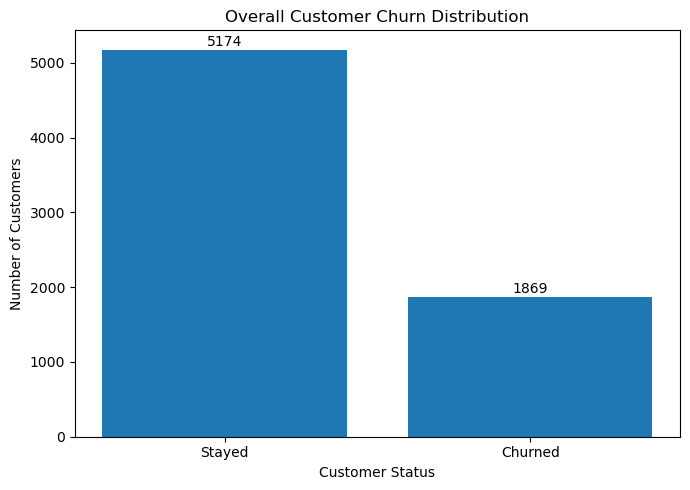

In [13]:
labels = ["Stayed", "Churned"]

plt.figure(figsize=(7, 5))

plt.bar(labels,churn_counts.values)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for index, value in enumerate(churn_counts.values):
    plt.text(index,value + 50,str(value),ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"overall_churn_distribution.png"),dpi=300)

plt.show()


In [14]:
def calculate_churn_rate(data, column):
    result = (data.groupby(column).agg(
            Total_Customers=("Churn", "count"),
            Churned_Customers=("Churn", "sum"),
            Churn_Rate=("Churn", "mean")
        ).reset_index())

    result["Churn_Rate"] = (result["Churn_Rate"] * 100).round(2)
    return result


Gender Churn Analysis:
   gender  Total_Customers  Churned_Customers  Churn_Rate
0  Female             3488                939       26.92
1    Male             3555                930       26.16


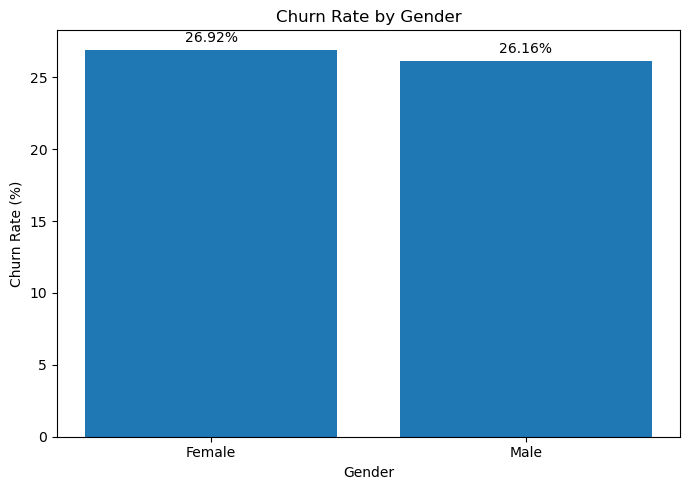

In [15]:
gender_analysis = calculate_churn_rate(df,"gender")

print("\nGender Churn Analysis:")
print(gender_analysis)

plt.figure(figsize=(7, 5))
plt.bar(gender_analysis["gender"],gender_analysis["Churn_Rate"])

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for index, value in enumerate(gender_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"churn_by_gender.png"),dpi=300)

plt.show()



Partner Status Churn Analysis:
  Partner  Total_Customers  Churned_Customers  Churn_Rate
0      No             3641               1200       32.96
1     Yes             3402                669       19.66


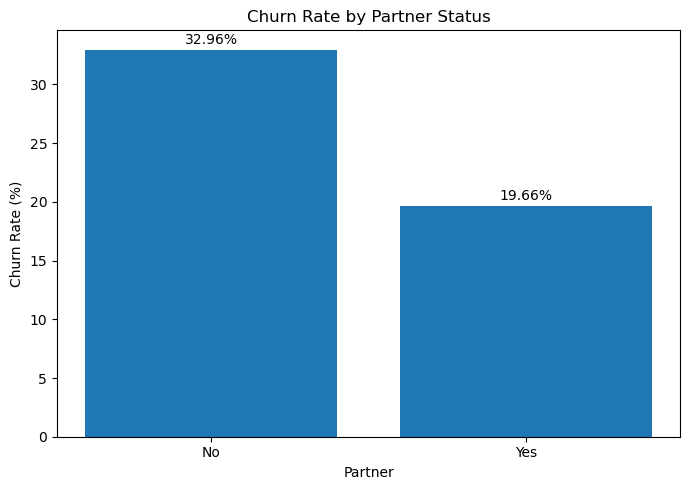

In [16]:
partner_analysis = calculate_churn_rate(df,"Partner")

print("\nPartner Status Churn Analysis:")
print(partner_analysis)

plt.figure(figsize=(7, 5))

plt.bar(partner_analysis["Partner"],partner_analysis["Churn_Rate"])

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")

for index, value in enumerate(partner_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"churn_by_partner.png"),dpi=300)

plt.show()



Dependents Churn Analysis:
  Dependents  Total_Customers  Churned_Customers  Churn_Rate
0         No             4933               1543       31.28
1        Yes             2110                326       15.45


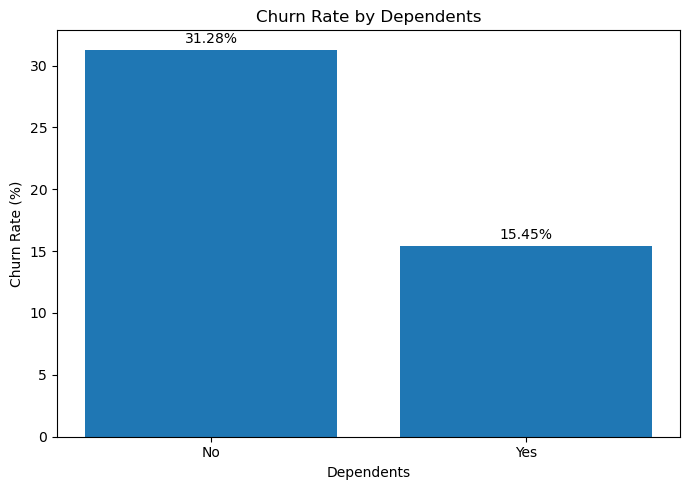

In [17]:
dependent_analysis = calculate_churn_rate(df,"Dependents")

print("\nDependents Churn Analysis:")
print(dependent_analysis)

plt.figure(figsize=(7, 5))

plt.bar(dependent_analysis["Dependents"],dependent_analysis["Churn_Rate"])

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")

for index, value in enumerate(dependent_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"churn_by_dependents.png"),dpi=300)

plt.show()

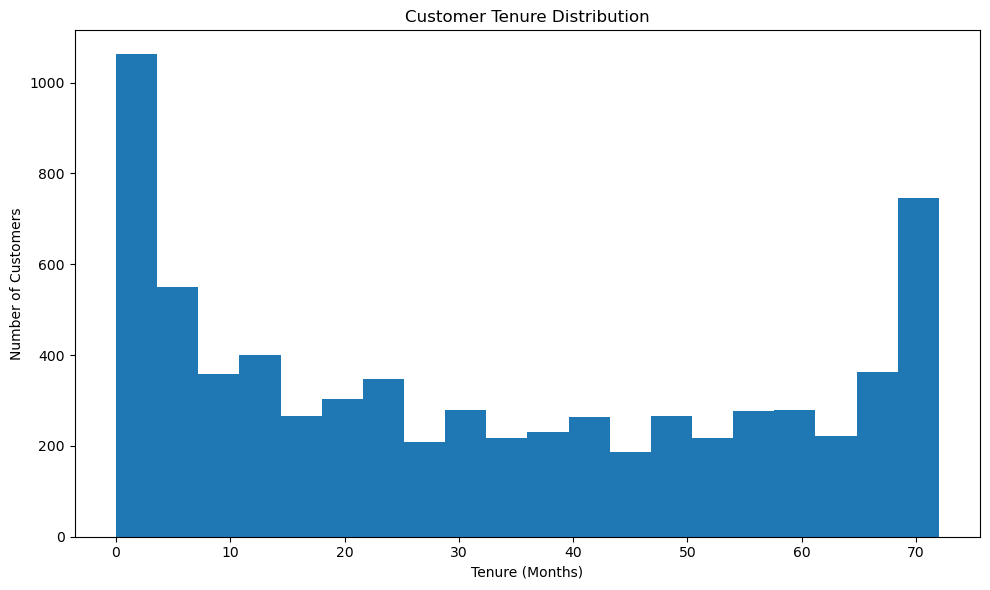

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(df["tenure"],bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"tenure_distribution.png"),dpi=300)

plt.show()

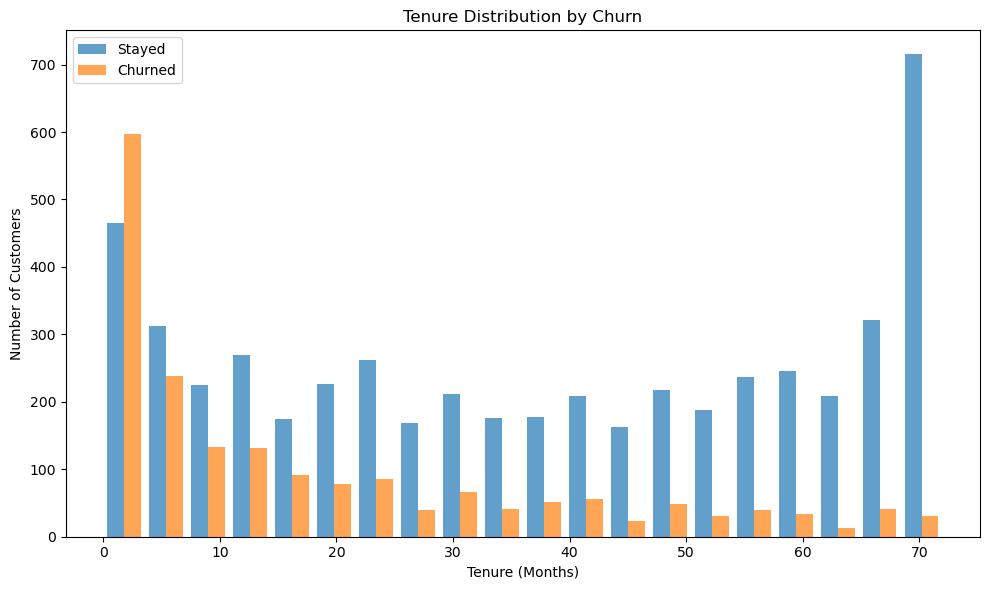

In [19]:
stayed_customers = df[df["Churn"] == 0]["tenure"]

churned_customers = df[df["Churn"] == 1]["tenure"]

plt.figure(figsize=(10, 6))

plt.hist([stayed_customers,churned_customers],bins=20,label=["Stayed","Churned"],alpha=0.7)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"tenure_vs_churn.png"),dpi=300)

plt.show()

In [20]:
tenure_churn_summary = (df.groupby("Churn")["tenure"].agg(["count","mean","median","min","max"]).round(2))

print("\nTenure Statistics by Churn:")
print(tenure_churn_summary)



Tenure Statistics by Churn:
       count   mean  median  min  max
Churn                                
0       5174  37.57    38.0    0   72
1       1869  17.98    10.0    1   72


In [21]:
df["TenureGroup"] = pd.cut(df["tenure"],bins=[-1,12,24,48,60,72],
    labels=["0-12 Months","13-24 Months","25-48 Months","49-60 Months","61-72 Months"])

C:\Users\vishal\AppData\Local\Temp\ipykernel_16116\801091043.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (data.groupby(column).agg(



Churn Rate by Tenure Group:
    TenureGroup  Total_Customers  Churned_Customers  Churn_Rate
0   0-12 Months             2186               1037       47.44
1  13-24 Months             1024                294       28.71
2  25-48 Months             1594                325       20.39
3  49-60 Months              832                120       14.42
4  61-72 Months             1407                 93        6.61


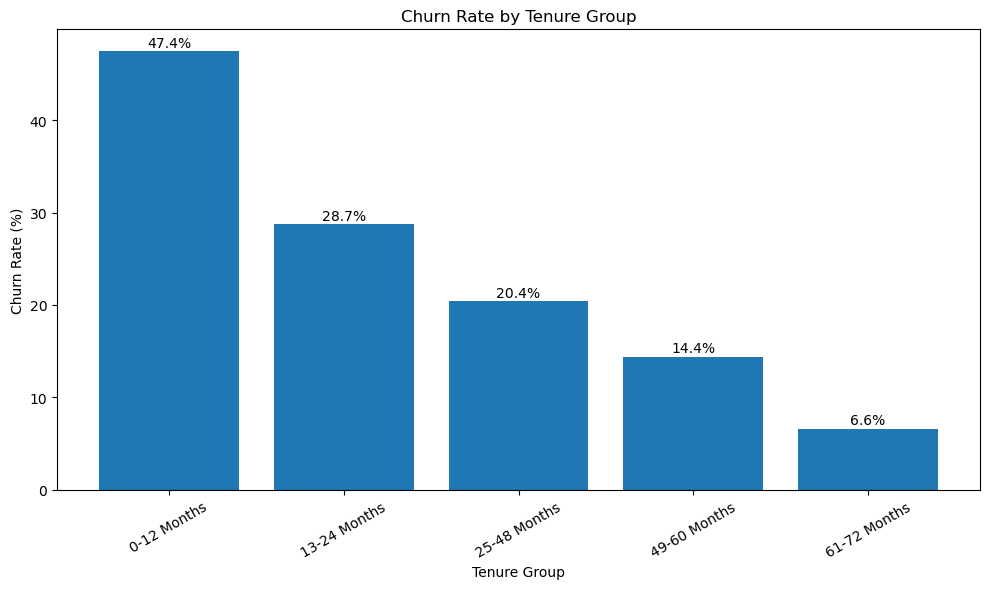

In [22]:
tenure_group_analysis = calculate_churn_rate(df,"TenureGroup")

print("\nChurn Rate by Tenure Group:")
print(tenure_group_analysis)

plt.figure(figsize=(10, 6))

plt.bar(tenure_group_analysis["TenureGroup"].astype(str),tenure_group_analysis["Churn_Rate"])

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

for index, value in enumerate(tenure_group_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.1f}%",ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"churn_by_tenure_group.png"),dpi=300)

plt.show()


Contract Type Churn Analysis:
         Contract  Total_Customers  Churned_Customers  Churn_Rate
0  Month-to-month             3875               1655       42.71
1        One year             1473                166       11.27
2        Two year             1695                 48        2.83


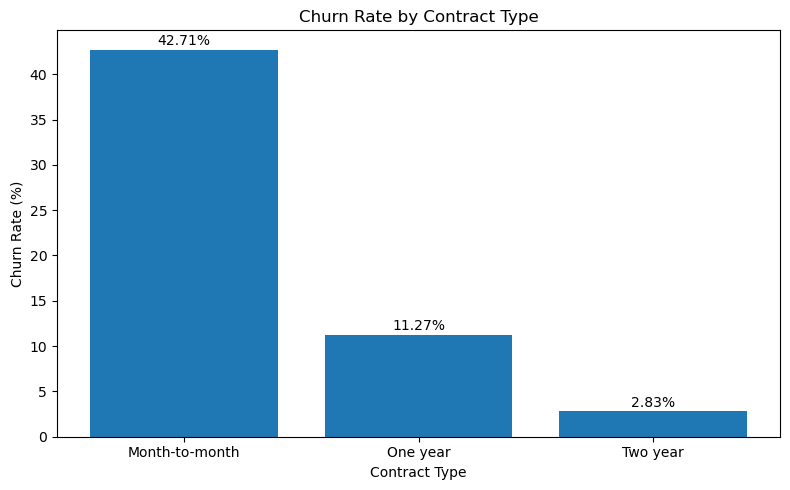

In [23]:
contract_analysis = calculate_churn_rate(df,"Contract")

contract_analysis = (contract_analysis.sort_values("Churn_Rate",ascending=False))

print("\nContract Type Churn Analysis:")
print(contract_analysis)

plt.figure(figsize=(8, 5))
plt.bar(contract_analysis["Contract"],contract_analysis["Churn_Rate"])

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for index, value in enumerate(contract_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"churn_by_contract.png"),dpi=300)

plt.show()



Payment Method Churn Analysis:
               PaymentMethod  Total_Customers  Churned_Customers  Churn_Rate
2           Electronic check             2365               1071       45.29
3               Mailed check             1612                308       19.11
0  Bank transfer (automatic)             1544                258       16.71
1    Credit card (automatic)             1522                232       15.24


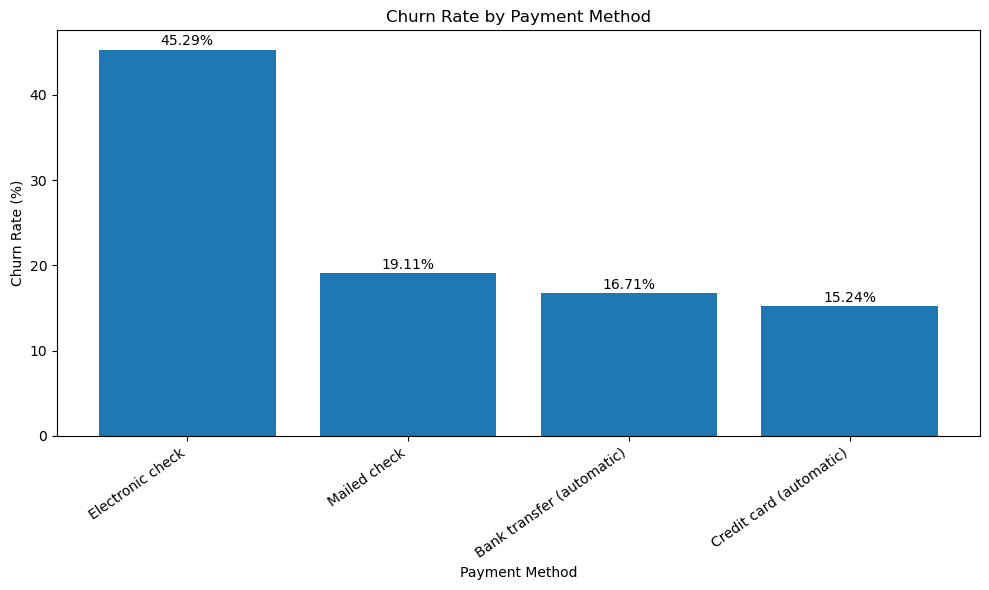

In [24]:
payment_analysis = calculate_churn_rate(df,"PaymentMethod")

payment_analysis = (payment_analysis.sort_values("Churn_Rate",ascending=False))

print("\nPayment Method Churn Analysis:")
print(payment_analysis)

plt.figure(figsize=(10, 6))

plt.bar(payment_analysis["PaymentMethod"],payment_analysis["Churn_Rate"])

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=35,ha="right")

for index, value in enumerate(payment_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"churn_by_payment_method.png"),dpi=300)

plt.show()


Monthly Charges by Churn:
       count   mean  median    min     max
Churn                                     
0       5174  61.27   64.43  18.25  118.75
1       1869  74.44   79.65  18.85  118.35


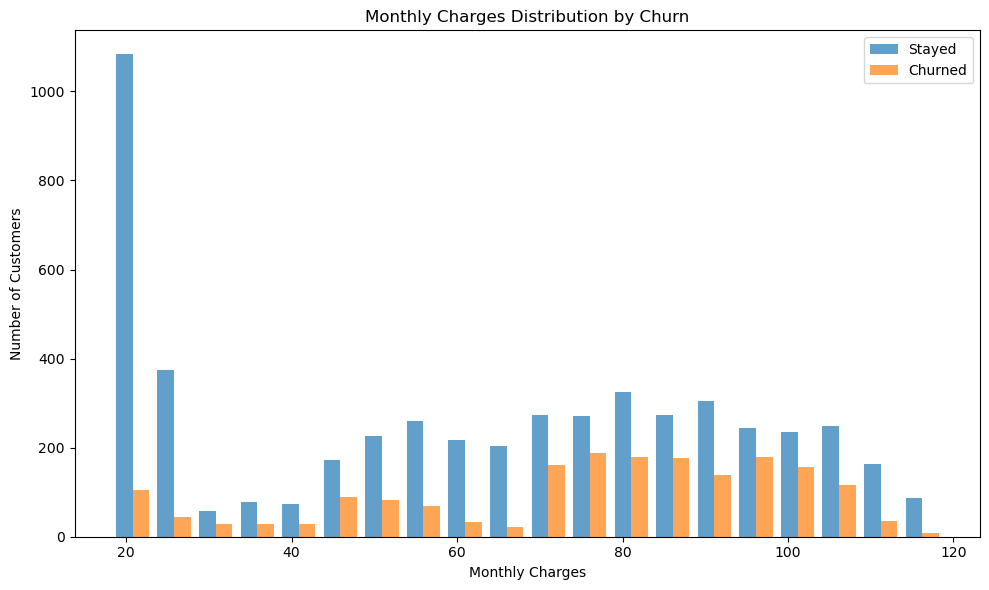

In [25]:
monthly_charge_summary = (df.groupby("Churn")["MonthlyCharges"].agg(
        ["count","mean","median","min","max"]).round(2))

print("\nMonthly Charges by Churn:")
print(monthly_charge_summary)

plt.figure(figsize=(10, 6))

plt.hist([df[df["Churn"] == 0]["MonthlyCharges"],df[df["Churn"] == 1]["MonthlyCharges"]],
    bins=20,label=["Stayed","Churned"],alpha=0.7)

plt.title("Monthly Charges Distribution by Churn")

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"monthly_charges_vs_churn.png"),dpi=300)

plt.show()

In [26]:
print("\n" + "=" * 60)

print("CUSTOMER CHURN EDA SUMMARY")

print("=" * 60)

overall_churn_rate = (df["Churn"].mean() * 100)

print(f"\nOverall Churn Rate: "f"{overall_churn_rate:.2f}%")

print("\nGender Analysis:")
print(gender_analysis[["gender","Churn_Rate"]])

print("\nPartner Analysis:")
print(partner_analysis[["Partner","Churn_Rate"]])

print("\nDependents Analysis:")
print(dependent_analysis[["Dependents","Churn_Rate"]])

print("\nContract Analysis:")
print(contract_analysis[["Contract","Churn_Rate"]])

print("\nPayment Method Analysis:")
print(payment_analysis[["PaymentMethod","Churn_Rate"]])

print("\nAverage Tenure by Churn:")
print(df.groupby("Churn")["tenure"].mean().round(2))

print("\nAverage Monthly Charges by Churn:")
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))


CUSTOMER CHURN EDA SUMMARY

Overall Churn Rate: 26.54%

Gender Analysis:
   gender  Churn_Rate
0  Female       26.92
1    Male       26.16

Partner Analysis:
  Partner  Churn_Rate
0      No       32.96
1     Yes       19.66

Dependents Analysis:
  Dependents  Churn_Rate
0         No       31.28
1        Yes       15.45

Contract Analysis:
         Contract  Churn_Rate
0  Month-to-month       42.71
1        One year       11.27
2        Two year        2.83

Payment Method Analysis:
               PaymentMethod  Churn_Rate
2           Electronic check       45.29
3               Mailed check       19.11
0  Bank transfer (automatic)       16.71
1    Credit card (automatic)       15.24

Average Tenure by Churn:
Churn
0    37.57
1    17.98
Name: tenure, dtype: float64

Average Monthly Charges by Churn:
Churn
0    61.27
1    74.44
Name: MonthlyCharges, dtype: float64


In [29]:
gender_analysis.to_csv("../artifacts/gender_churn_analysis.csv",index=False)

partner_analysis.to_csv("../artifacts/partner_churn_analysis.csv",index=False)

dependent_analysis.to_csv("../artifacts/dependent_churn_analysis.csv",index=False)

tenure_group_analysis.to_csv("../artifacts/tenure_churn_analysis.csv",index=False)

contract_analysis.to_csv("../artifacts/contract_churn_analysis.csv",index=False)

payment_analysis.to_csv("../artifacts/payment_method_churn_analysis.csv",index=False)

